# Level 1 — Task 3: Data Preprocessing for Machine Learning

### Load Processed Datasets

This project uses the processed datasets generated during Task 1.

Using the processed data ensures that:
- Missing values have already been handled.
- Categorical variables have already been encoded.
- Numerical features have already been standardized.
- Data leakage is avoided because preprocessing was fit only on the training data.

The KNN model will be trained using the processed training set and evaluated on the processed testing set.

In [32]:
import sys
from pathlib import Path

ROOT = Path.cwd().parents[2] # Go up two directories

# Add project root to Python's module search path so notebook can import from src/
if str(ROOT) not in sys.path: # Prevent duplicate path entries
    sys.path.append(str(ROOT)) # Add project root

DATA_DIR = ROOT / "data"

In [33]:
import pandas as pd

# Processed data directory
PROCESSED_DIR = DATA_DIR / "processed" / "churn"

# Load training data
X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv")

# Load testing data
X_test = pd.read_csv(PROCESSED_DIR / "X_test.csv")
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv")

# Verify datasets loaded correctly
for obj, label in [(X_train, "X_train"), (X_test, "X_test"), 
                   (y_train, "y_train"), (y_test, "y_test")]:
    print(f"{label} shape: {obj.shape}")

X_train shape: (2666, 14)
X_test shape: (667, 14)
y_train shape: (2666, 1)
y_test shape: (667, 1)


### Target Variable datatype for sklearn

Sklearn expects the target `y` to be a 1D Series or NumPy array, not a DataFrame.
A `(n, 1)` DataFrame is technically 2D, which triggers a 'DataConversionWarning' warning.

We use `.squeeze()` to flatten it into a Series before fitting.

In [34]:
# Check y_train and y_test types
print(f"y_train type: {type(y_train)}")
print(f"y_test type: {type(y_test)}")

y_train type: <class 'pandas.DataFrame'>
y_test type: <class 'pandas.DataFrame'>


In [35]:
# Convert single-column DataFrames into Series
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print(f"y_train type: {type(y_train)}")
print(f"y_test type: {type(y_test)}")

y_train type: <class 'pandas.Series'>
y_test type: <class 'pandas.Series'>


### K-Nearest Neighbors (KNN)

KNN is a supervised algorithm used for classification and regression. We'll use KNN for binary classification in order to predict customer churn.

When predicting a new observation, KNN:

1. Calculates the distance between the new observation and all training examples.
2. Finds the K closest training examples (neighbors).
3. Uses a majority vote among those neighbors to determine the predicted class.

For example, if K = 5 and 3/5 nearest neighbors belong to the "Churn" class, the model predicts that the new customer will churn.

In [36]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize classifier
knn = KNeighborsClassifier() # dafault k=5

# Train classifier
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


KNN is considered a "lazer learner" meaning when you fit the model it doesn't learn parameters. KNN stores the feature values (`X_train`) and corresponding labels (`y_train`) during fitting. Each row of `X_train` represents a data point in a multi-dimensional feature space, which is why feature scaling is crucial to prevent large-ranged features from dominating distance calculations. `y_train` stores the corresponding class label (e.g., `True` or `False`) for each point.

During predictions is when heavy computational work happens. KKN calculates the distances, find the k-nearest neighbors, and uses those points to make a prediction.

In [37]:
# Generate predictions on the test set
y_pred = knn.predict(X_test)

### Model Evaluation

After making predictions on the test set, we evaluate the model's performance on the unseen data.

For this classification task, we use:

- Accuracy: proportion of correctly classified predictions (`correct preds/total preds`)

- Confusion Matrix: table that breaks down predictions into true positives, true negatives, false positives, and false negatives

- Precision: out of all positive predictions, how many were correct? `TP / (TP + FP)`

- Recall: out of all positives, how many did the model predict correctly? `TP / (TP + FN)`

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
test_false_proportion = y_test.value_counts(normalize=True)[False]

# Print results rounded to 2 decimals
print(f"Accuracy: {accuracy:.2f}")
print(f"Test false proportion: {test_false_proportion:.2f}")

Accuracy: 0.88
Test false proportion: 0.86


Because the dataset is imbalanced (85% false 15% true), accuracy alone isn't a sufficient metric. The model could predict false for all of the data and still have 85% which is high on paper but completely useless, it never detects a single true case.

In this case the accuracy was **88%** which is high but compared to our baseline of **86%**, that's only a **2.%** improvement over the model guessing false for every prediction.

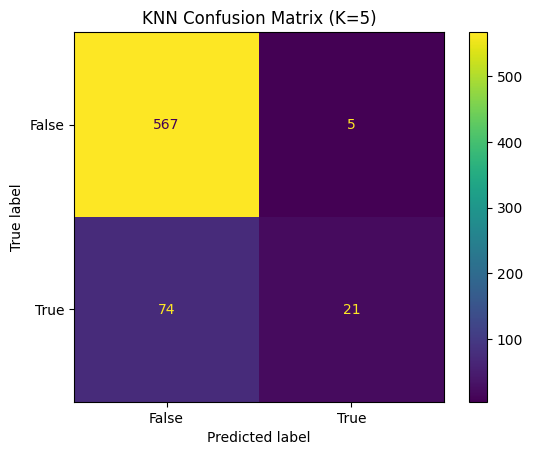

In [39]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import pyplot as plt

# Initialize confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot cm
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn.classes_
)

disp.plot()
plt.title("KNN Confusion Matrix (K=5)")
plt.show()

The results from the confusion matrix:

- 567 actually `false`, predicted **false** (TN)

- 5 actually `false`, predicted **true** (FP)

- 74 actually `true`, predicted **false** (FN)

- 21 actually `true`, predicted **true** (TP)

Evaluation: the model is great at predicting non-churners, as only 5 of the true predictions were false. On the other hand out of 95 churners, the model only predicted 21 while incorrectly predicting 74. 21/99 = ~22.1, so the model only predicted about 22% of the customers that churned.

This suggests that the model is relatively conservative when predicting churn. It rarely labels customers as churners, which keeps false alarms low, but it also causes many actual churners to be missed.

For a churn prediction problem, this behavior may not align with business objectives if retaining at-risk customers is a priority.

### Customer Churn Dillemma

Suppose in this case the business cares more on identifying customers likely to churn than accidentlly flagging a few loyal customers as potential churners. In other words, they prioritize minimizing **False Negatives** over False Positives.

In [40]:
from sklearn.metrics import precision_score, recall_score

# Calculate precision and recall
precision = precision_score(y_test, y_pred) # TP / (TP + FP)
recall = recall_score(y_test, y_pred) # TP / (TP + FN)

print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")

Precision: 0.81
Recall:    0.22


### Precision and Recall
- Model has a precision of **81%** which is a solid score. This indicates that when it predicts a customer will churn, it is usually correct.
- However, the model has a recall of **22%** which is poor. This means the model identifies only a small fraction of customers who actually churn.

High precision and low recall suggests the model only predicts churn (true) when it is highly confident, as a result, it produces few false positives but misses many actual churners. In other words, the model is relatively **conservative** when predicting churn.

In [ ]:
from sklearn.metrics import classification_report

# Print full classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.88      0.99      0.93       572
        True       0.81      0.22      0.35        95

    accuracy                           0.88       667
   macro avg       0.85      0.61      0.64       667
weighted avg       0.87      0.88      0.85       667



## KNN Churn Model Evaluation

The model performs well on the majority class (false/no churn) with an F1 of 0.93, but struggles with actual churners. 0.22 means it misses ~78% of them.

Despite an 88% overall accuracy, this is misleading given the class imbalance. The low F1 of 0.35 for the true class confirms the model is not reliable for identifying customers with high likeliness of churning.

### Choosing K

- Small K values can be sensitive to noise and may overfit.
- Large K values create smoother decision boundaries but may underfit.